In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("btcusd_1-min_data.csv")

In [3]:
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


In [4]:
print(df.shape)

(7663772, 6)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7663772 entries, 0 to 7663771
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 350.8 MB
None


In [6]:
print(df.head())

    Timestamp  Open  High   Low  Close  Volume
0  1325376060  4.58  4.58  4.58   4.58     0.0
1  1325376120  4.58  4.58  4.58   4.58     0.0
2  1325376180  4.58  4.58  4.58   4.58     0.0
3  1325376240  4.58  4.58  4.58   4.58     0.0
4  1325376300  4.58  4.58  4.58   4.58     0.0


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df['Date'] = pd.to_datetime(df['Timestamp'], unit='s')

In [10]:

df['Year'] = df['Date'].dt.year


In [11]:
df['Month'] = df['Date'].dt.month_name()

In [12]:
df['Month No'] = df['Date'].dt.month

In [14]:
df['Quarter'] = df['Date'].dt.quarter

In [15]:
df['Day'] = df['Date'].dt.day


In [16]:
df['Week Day'] = df['Date'].dt.day_name()

In [17]:
print(df.isnull().sum())

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
Date         0
Year         0
Month        0
Month No     0
Quarter      0
Day          0
Week Day     0
dtype: int64


In [18]:
df = df.dropna()

In [19]:
df = df.drop_duplicates()


In [20]:
df = df[df['Volume'] >= 0]


In [21]:
price_cols = ['Open','High','Low','Close']


In [22]:
df[price_cols] = df[price_cols].round(2)


In [23]:
daily_df = df.groupby(df['Date'].dt.date).agg(
    Open=('Open','first'),
    High=('High','max'),
    Low=('Low','min'),
    Close=('Close','last'),
    Volume=('Volume','sum')
).reset_index()

In [24]:
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

daily_df['Year'] = daily_df['Date'].dt.year
daily_df['Month'] = daily_df['Date'].dt.month_name()
daily_df['Month No'] = daily_df['Date'].dt.month
daily_df['Quarter'] = daily_df['Date'].dt.quarter
daily_df['Week Day'] = daily_df['Date'].dt.day_name()

In [25]:
daily_df.to_csv("Bitcoin_Cleaned_Daily.csv", index=False)

In [26]:
print(daily_df.head())
print(daily_df.shape)

print("CSV Saved Successfully")

        Date  Open  High   Low  Close      Volume  Year    Month  Month No  \
0 2012-01-01  4.58  5.00  4.58   5.00   21.602000  2012  January         1   
1 2012-01-02  5.00  5.00  5.00   5.00   19.048000  2012  January         1   
2 2012-01-03  5.00  5.32  5.00   5.29   88.037281  2012  January         1   
3 2012-01-04  5.29  5.57  4.93   5.57  107.233260  2012  January         1   
4 2012-01-05  5.57  6.65  5.57   6.65   94.801829  2012  January         1   

   Quarter   Week Day  
0        1     Sunday  
1        1     Monday  
2        1    Tuesday  
3        1  Wednesday  
4        1   Thursday  
(5323, 11)
CSV Saved Successfully


In [27]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,Year,Month,Month No,Quarter,Day,Week Day
0,1325376060,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:01:00,2012,January,1,1,1,Sunday
1,1325376120,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:02:00,2012,January,1,1,1,Sunday
2,1325376180,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:03:00,2012,January,1,1,1,Sunday
3,1325376240,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:04:00,2012,January,1,1,1,Sunday
4,1325376300,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:05:00,2012,January,1,1,1,Sunday


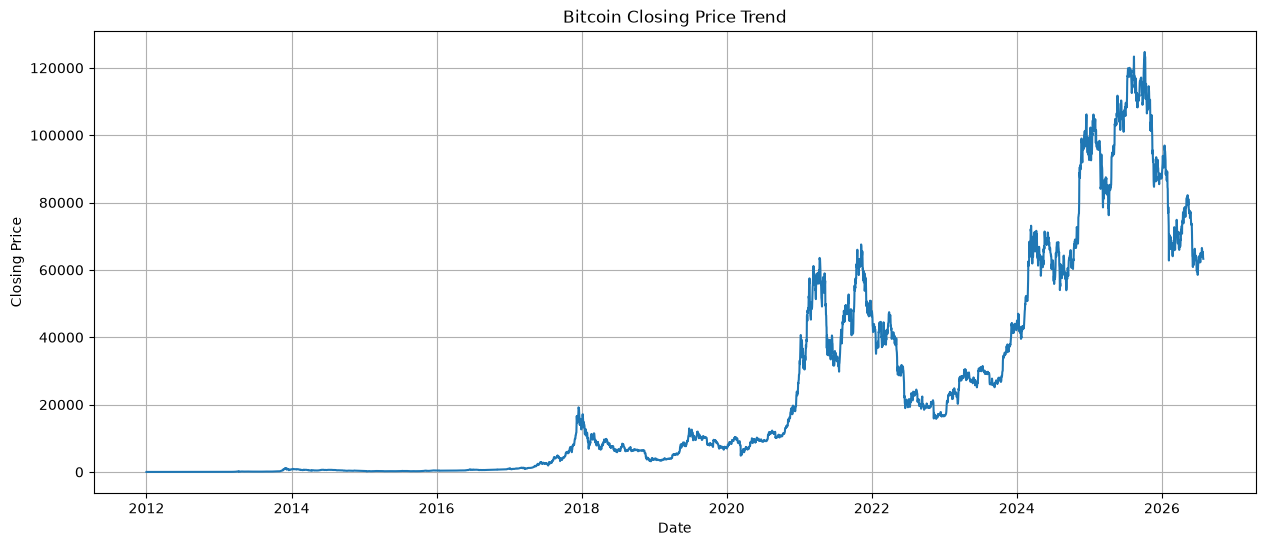

In [29]:
plt.figure(figsize=(15,6))
plt.plot(daily_df['Date'], daily_df['Close'])
plt.title("Bitcoin Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

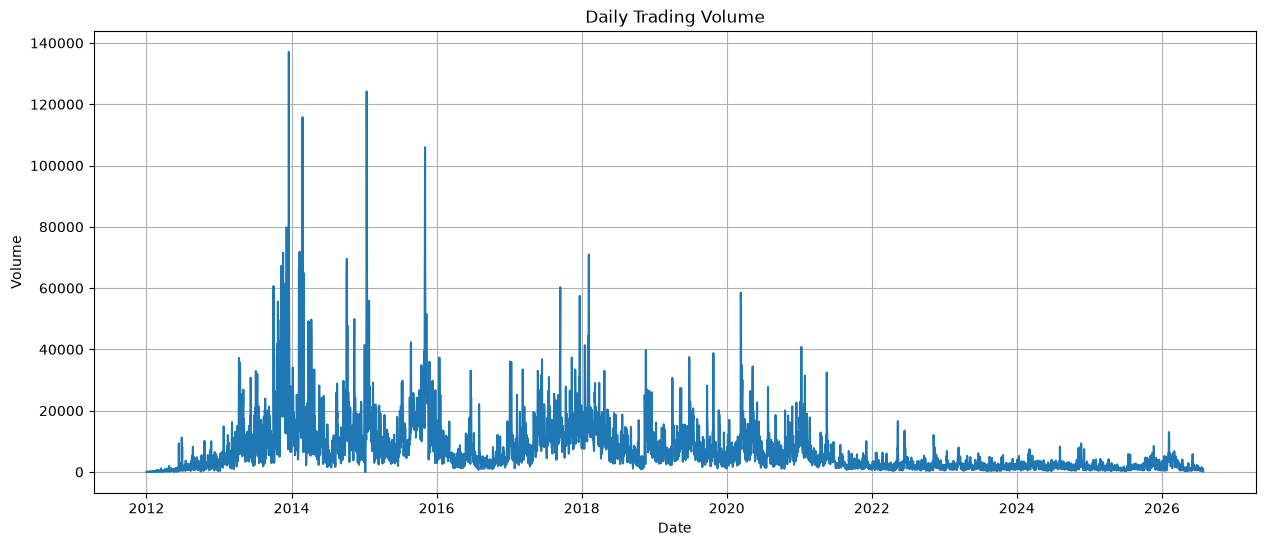

In [30]:
plt.figure(figsize=(15,6))
plt.plot(daily_df['Date'], daily_df['Volume'])
plt.title("Daily Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

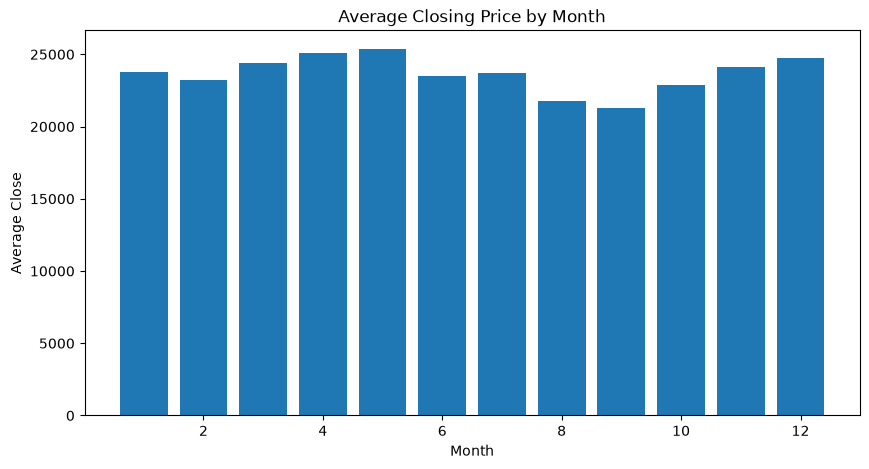

In [31]:
monthly = daily_df.groupby("Month No")["Close"].mean()

plt.figure(figsize=(10,5))
plt.bar(monthly.index, monthly.values)

plt.title("Average Closing Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Close")
plt.show()

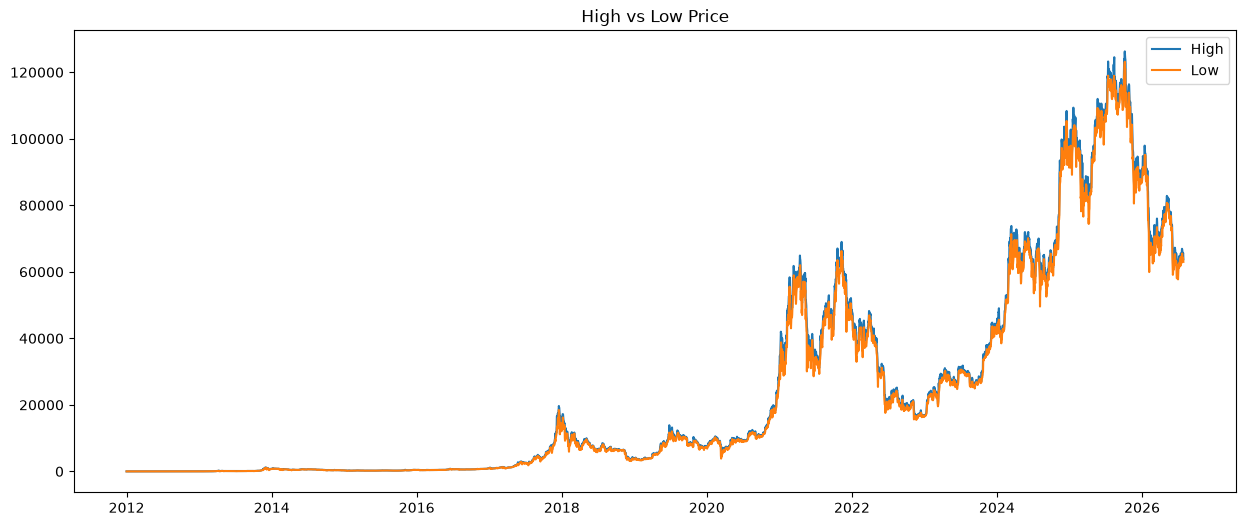

In [32]:
plt.figure(figsize=(15,6))

plt.plot(daily_df["Date"],daily_df["High"],label="High")

plt.plot(daily_df["Date"],daily_df["Low"],label="Low")

plt.legend()

plt.title("High vs Low Price")

plt.show()

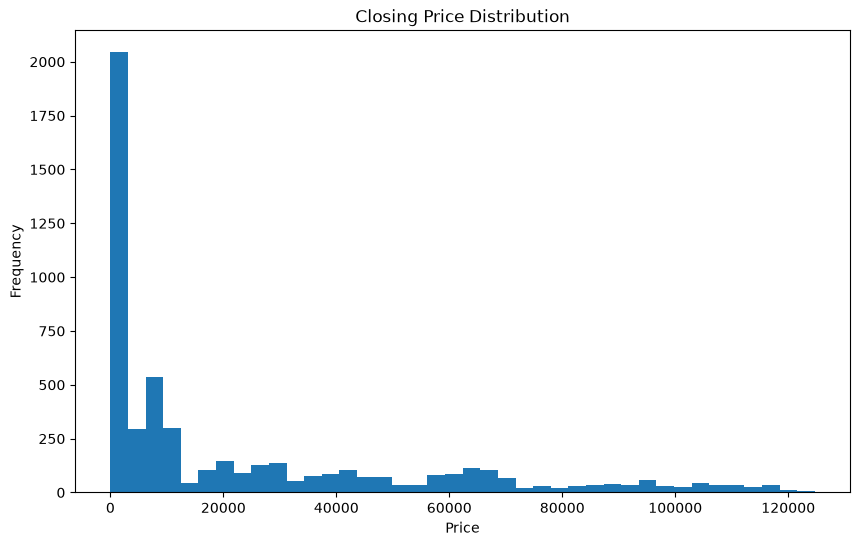

In [33]:
plt.figure(figsize=(10,6))

plt.hist(daily_df["Close"],bins=40)

plt.title("Closing Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

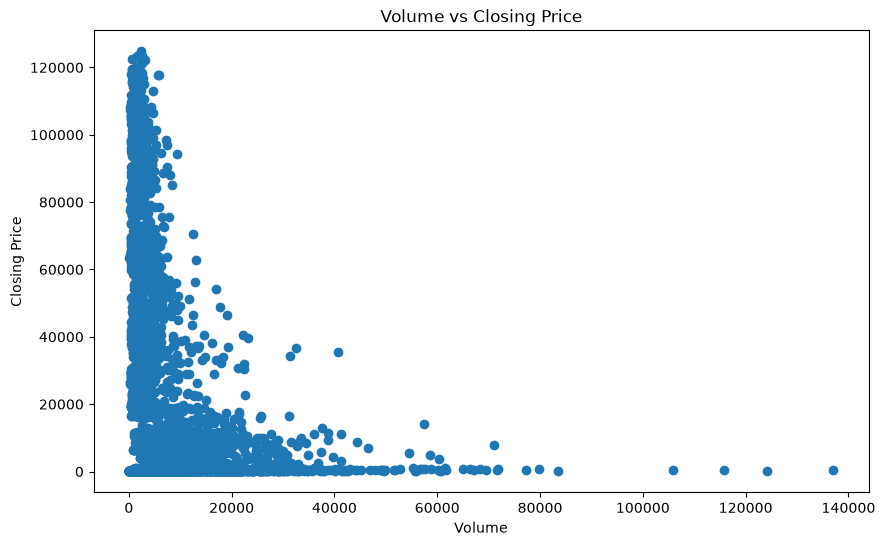

In [34]:
plt.figure(figsize=(10,6))

plt.scatter(
    daily_df["Volume"],
    daily_df["Close"]
)

plt.title("Volume vs Closing Price")

plt.xlabel("Volume")

plt.ylabel("Closing Price")

plt.show()

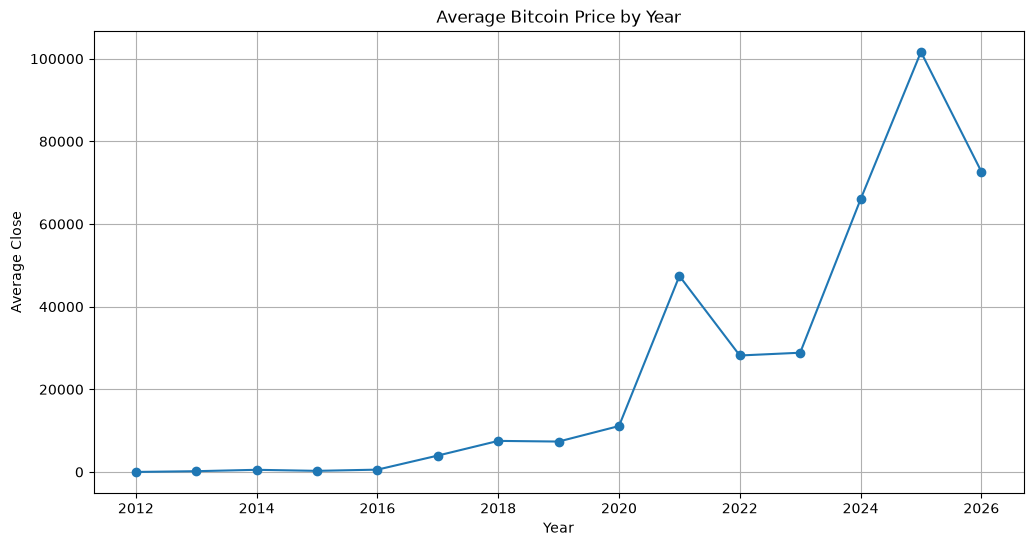

In [35]:
yearly=daily_df.groupby("Year")["Close"].mean()

plt.figure(figsize=(12,6))

plt.plot(yearly.index,yearly.values,marker="o")

plt.title("Average Bitcoin Price by Year")

plt.xlabel("Year")

plt.ylabel("Average Close")

plt.grid()

plt.show()

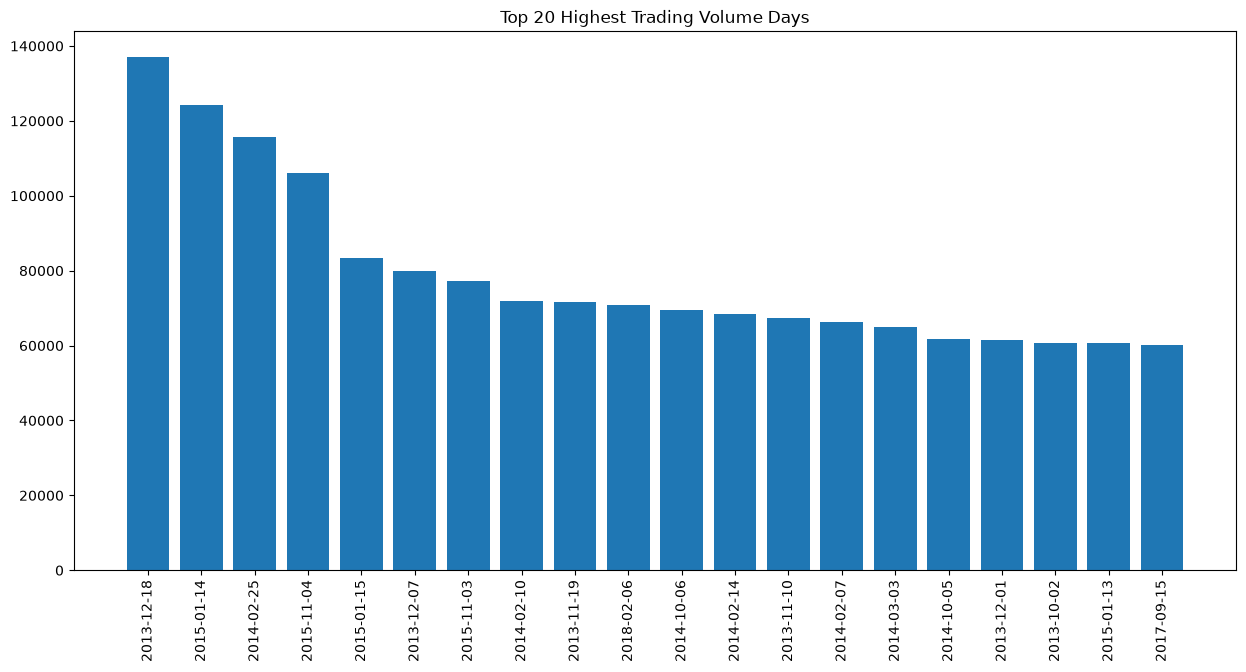

In [36]:
top20=daily_df.nlargest(20,"Volume")

plt.figure(figsize=(15,7))

plt.bar(
top20["Date"].astype(str),
top20["Volume"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Highest Trading Volume Days")

plt.show()

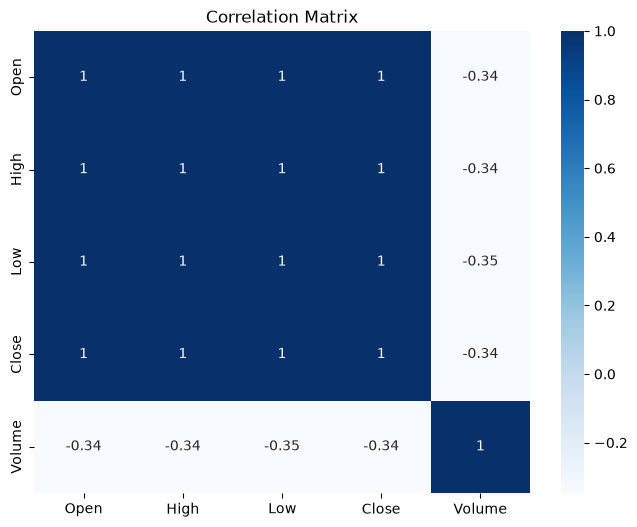

In [37]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
daily_df[
["Open","High","Low","Close","Volume"]
].corr(),
annot=True,
cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

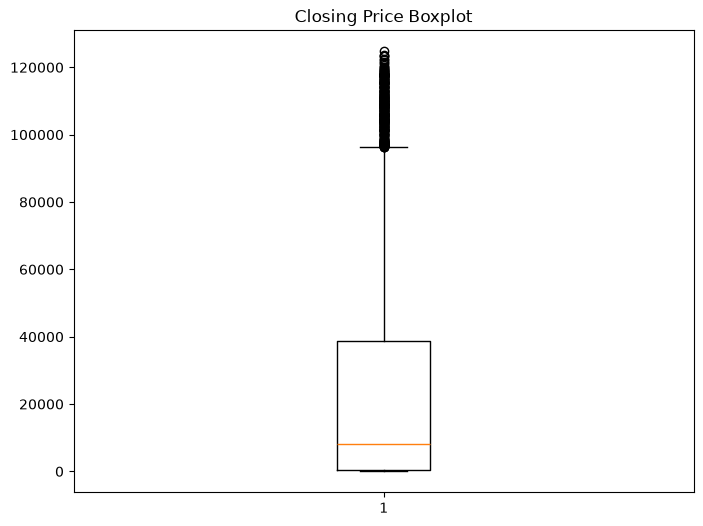

In [38]:
plt.figure(figsize=(8,6))

plt.boxplot(daily_df["Close"])

plt.title("Closing Price Boxplot")

plt.show()